In [ ]:
import os
print(os.getcwd())

/home/alesau/mllm/mllm-listeners


In [2]:
from models.mllm_wrappers import LLaVA, Qwen, Janus, Qwen3_5, Molmo
from configuration_template import Config

config = Config()
config.input_type = 'simple'
config.task = 'grid'

img_kwargs = {
        "patch_size": config.patch_size,
        "patch_padding": config.patch_padding,
        "grid_padding": config.grid_padding,
        "patch_pad_color": config.patch_pad_color,
        "grid_pad_color": config.grid_pad_color,
    }

generate_kwargs = {
        "max_new_tokens": config.max_new_tokens,
        "do_sample": True,
        "temperature": 0.8
    }

model_kwargs = {"cache_dir": config.model_cache_dir, "quant": config.quant}






/home/alesau/miniconda3/envs/mllm/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model_version: Qwen2
model_type: Qwen


In [9]:
Model = Qwen
model = Model(config.model_id, **model_kwargs)
print(f'Model: {model.__class__}')

building Qwen model...


Loading weights: 100%|██████████| 729/729 [00:01<00:00, 485.60it/s]
Some parameters are on the meta device because they were offloaded to the cpu.
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model: <class 'models.mllm_wrappers.Qwen'>


In [11]:
## set randomness
model_mode = 'random'

if model_mode == 'random':
    ## set randomness
    model.model.generation_config.temperature = 0.7
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.9
    model.model.generation_config.top_k = 50
else:
    ## set deterministic
    model.model.generation_config.temperature = 0.01
    model.model.generation_config.do_sample = True
    model.model.generation_config.top_p = 0.001
    model.model.generation_config.top_k = 1



In [12]:
# define prompts
TOP_INSTRUCTION = 'In this image you can see three color grids. In the following dialogue, the speaker will describe exactly one of the grids. Please indicate to me whether he refers to the left, middle or right grid.'
BOTTOM_PROMPT = 'Is it the left, middle or right grid?'


##Prompt 1
#SPEAKER_PROMPT_ONE = 'In this image you can see three color grids. Describe the'
#SPEAKER_PROMPT_TWO = 'grid in such a way, that I can identify it among the three grids. You can refer to the color, position and number of objects in the grid, but not to the grid as a whole. Do not refer to the grid as left, middle or right.'


##Prompt 2
SPEAKER_PROMPT_ONE = 'You see three images with each one having a different color grid. Describe the'
SPEAKER_PROMPT_TWO = 'grid in such a way, that I can identify it among the three grids. You can refer to the color, position and number of objects in the grid, but not to the grid as a whole. Do not refer to the grid as first, second or third. Do not describe the whole grid, if not necessary. You can also just describe one or two objects in the grid, if that is sufficient to identify it. Focus on the most distinctive features of the grid.'


In [13]:
import pandas as pd
import os.path as osp
data_df = pd.read_json(osp.join(config.data_dir, "color_grid_data.json"))
new_responses = []
old_responses = []

In [15]:
####Qwen2-VL-2B-Instruct


from data_prep.data_utils import build_images, build_grid_image_with_target_highlight


old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    images = build_images(entry.objs, entry.speaker_order, **img_kwargs)
    grid = build_grid_image_with_target_highlight(entry.objs, entry.speaker_order, entry.target, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "first"
    elif entry.target == 1:
        position = "second"
    elif entry.target == 2:
        position = "third"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate_single_images(full_prompt, image1=images[0], image2=images[1], image3=images[2], **generate_kwargs)
    display(grid)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

ImportError: cannot import name 'build_images' from 'data_prep.data_utils' (/home/alesau/mllm/mllm-listeners/data_prep/data_utils.py)

Qwen3-VL-2B-Instruct
Entry 2271


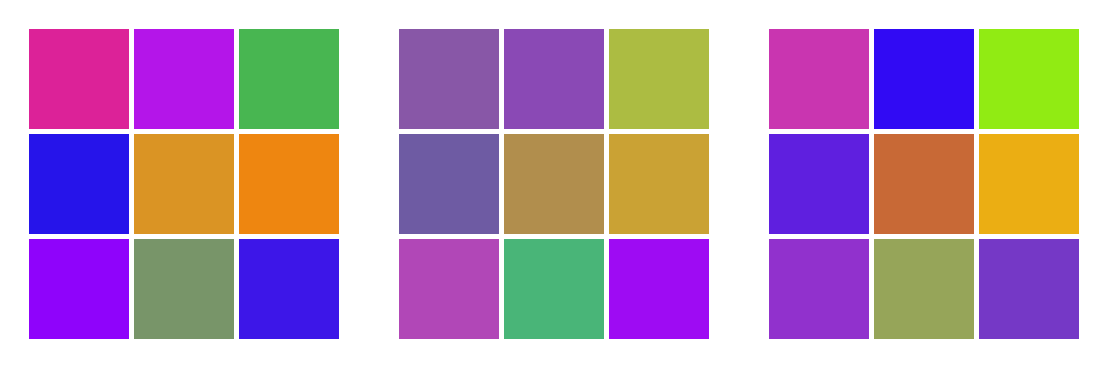

Position described by speaker: left
Response sentence: The leftmost grid has the most distinct visual characteristics. It is the only grid that contains a single object of a color that is not a standard color. This object is a purple square that stands out due to its vibrant hue, which contrasts with the other colors in the grid. The grid is composed of three rows and four columns, with a total of twelve squares. The other grids have different color schemes and patterns. The second grid has a greenish-yellow color, and the third grid has a combination of colors including purple, blue, and yellow. The left grid's distinct feature is the presence of this single, non-standard colored square. 


Entry 8698


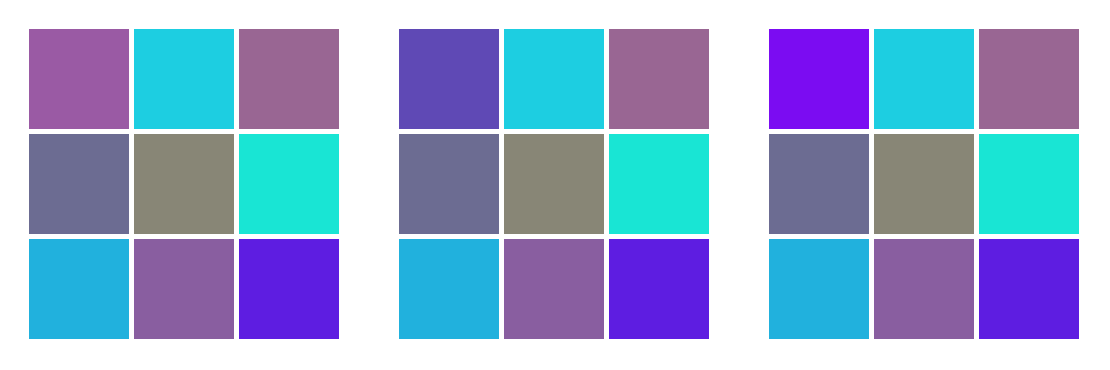

Position described by speaker: left
Response sentence: The left grid is distinguished by its use of two primary colors: a bright teal and a muted purple. It features a layout with five vertical columns and three rows. The most notable feature is the presence of two vertical columns with a single, bright teal color, which stands out due to its brightness against the purple background. The overall pattern is structured with these teal and purple blocks arranged in a grid. 


Entry 3753


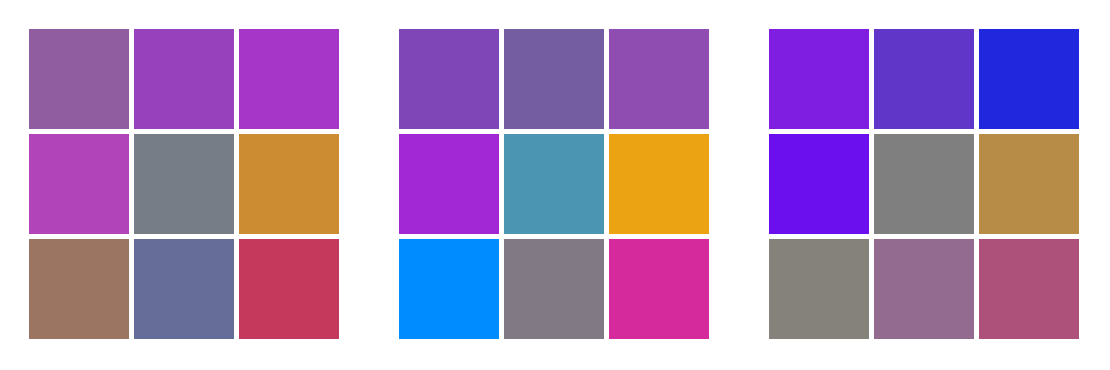

Position described by speaker: right
Response sentence: The rightmost grid is distinguished by its color scheme and the presence of a prominent blue square. Specifically, the grid contains a single blue square, which is the most visually distinct element among the three. This blue square is located in the top row, in the center of the grid, and is positioned directly above the rest of the squares. This unique placement and color make it stand out. Additionally, the grid has a total of 12 squares, which is consistent with the other two grids, but the blue square is the most distinctive feature. The other two grids have a different color scheme, with the middle grid featuring a yellow square, and the left grid featuring a pink square. Therefore, the right grid is identified by the presence of the 


Entry 8665


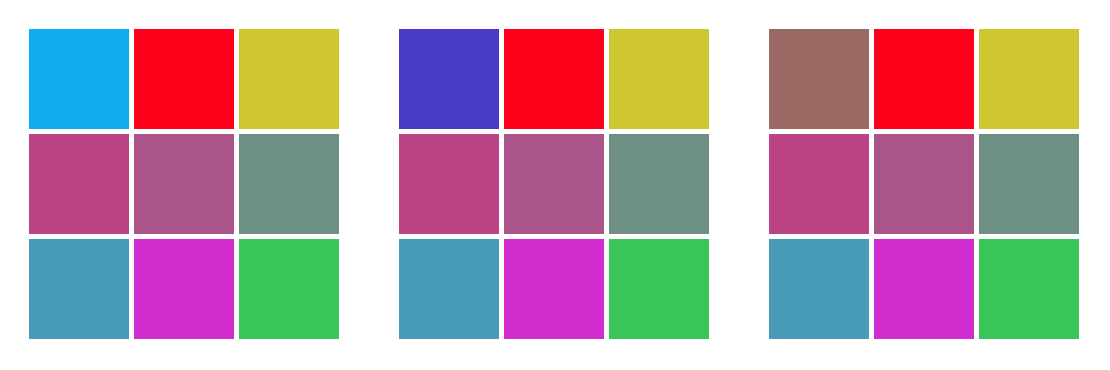

Position described by speaker: left
Response sentence: The leftmost grid is distinguished by its top row containing three bright red squares, which are noticeably more vibrant than the other colors. The grid is also characterized by a blue square in the second row, located at the far left, which stands out due to its distinct color and position. Additionally, the middle of the grid contains a prominent purple square, which is more vivid than the other colors, and is located in the second row, further distinguishing it from the others. These features—specific colors and their positions—help identify the left grid. 


Entry 4441


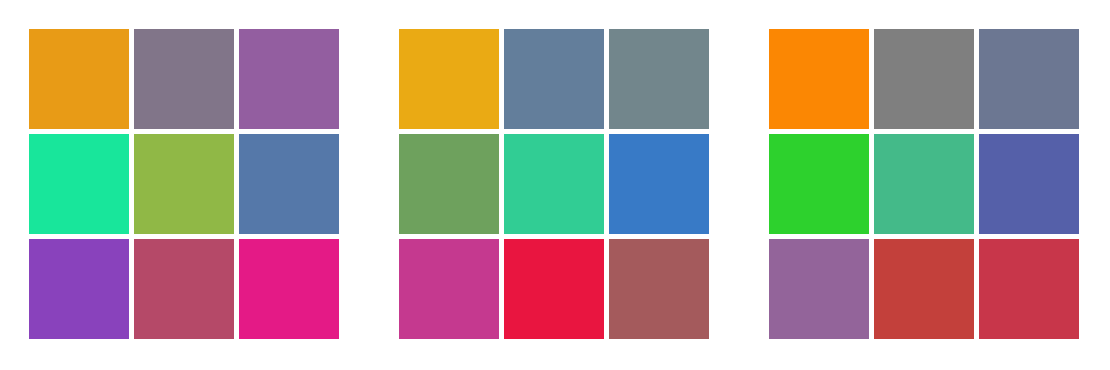

Position described by speaker: left
Response sentence: The leftmost grid is distinguished by its arrangement of colors and the presence of a prominent, centrally located yellowish-orange square. This square is positioned in the upper row and appears to be the most dominant color in the grid. The grid also contains other squares, with one in the lower row being a bright pink, which contrasts with the other colors. The overall composition is distinct, with a notable emphasis on the yellowish-orange square, making it a key identifier for the left grid. 




In [7]:
####Qwen3-VL-2B-Instruct
print("Qwen3-VL-2B-Instruct")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Qwen3.5-0.8B
Entry 2271


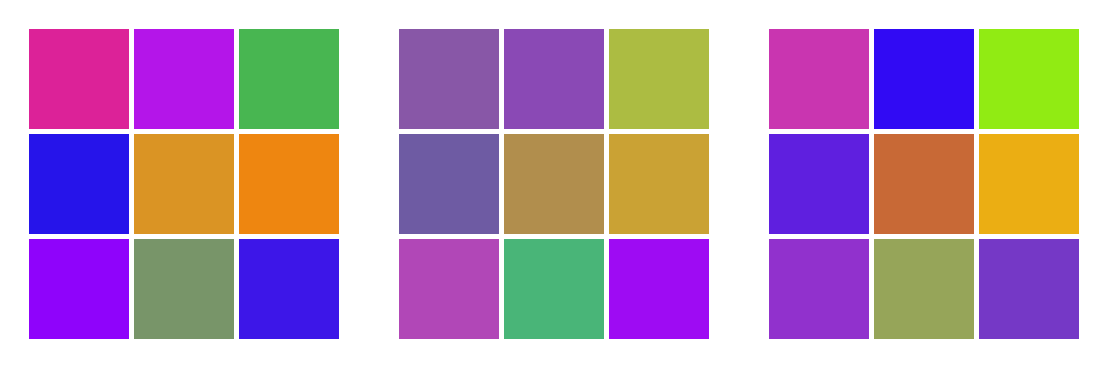

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The leftmost grid is composed of nine squares arranged in a 3x3 layout. Each square contains a distinct color and a specific geometric shape. The top row features a pink square with a star shape, a purple square with a heart shape, and a green square with a lightning bolt shape. The middle row displays an orange square with a circle, a purple square with a heart shape, and a brown square with a circle. The bottom row contains a blue square with a circle, a purple square with a heart shape, and a pink square with a circle. The distinctive features of this grid include the variety of shapes and colors, the even distribution of shapes within each square, and the distinct arrangement of the colors.
 


Entry 8698


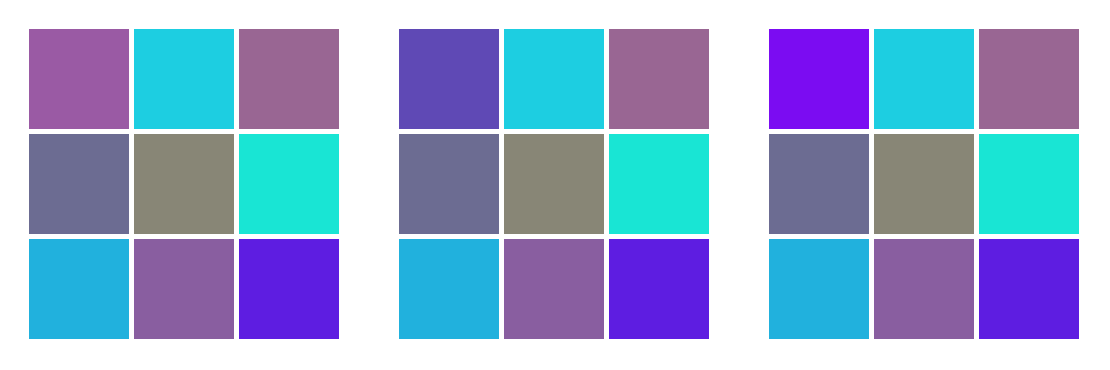

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid consists of four distinct colored squares arranged in a 2x2 structure.

- **Top-left square**: A medium-purple square.
- **Bottom-left square**: A medium-blue square.
- **Top-right square**: A medium-light blue-green square.
- **Bottom-right square**: A medium-dark purple square.

These colors and positions are highly distinct and help distinguish this grid from the others.
 


Entry 3753


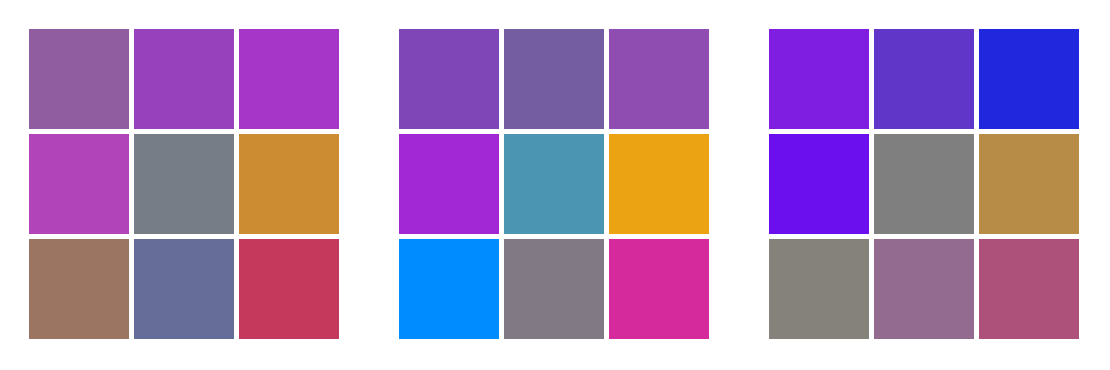

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The rightmost grid is a 3x6 grid of colorful squares, each square representing a unique color. The squares are arranged in rows and columns, and each square has a distinct color. The colors are: purple, blue, blue, blue, red, blue, blue, blue, purple, blue, blue, blue, blue, blue, purple, purple, red, red, red, purple, red, red, blue, blue, blue, blue, blue, purple, blue, purple, blue, blue, blue, blue, purple, red, red, blue, blue, blue, blue, blue, purple, blue, purple, blue, blue, blue, blue, blue, purple, red, red, blue 


Entry 8665


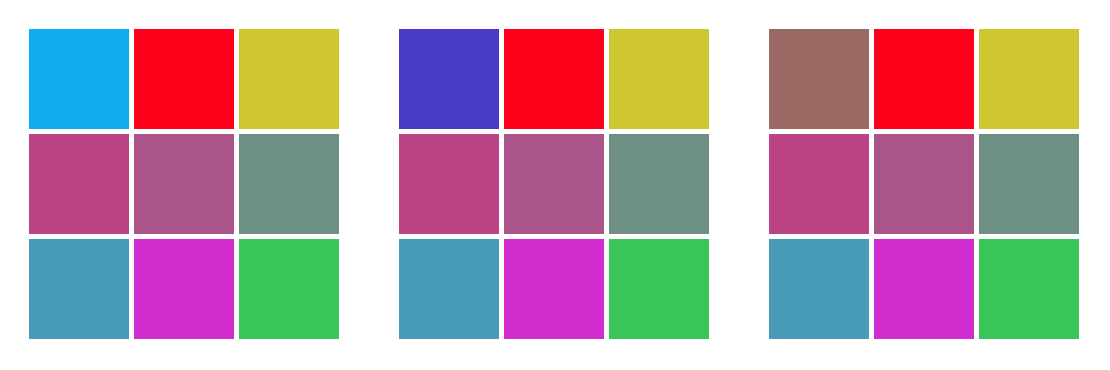

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid consists of three colored blocks arranged in three horizontal rows and three vertical columns, forming a 3x3 grid. The top row contains three squares: the first is a cyan square, the second is a red square, and the third is a gold square. The middle row includes three squares: the first is a maroon square, the second is a green square, and the third is a maroon square. The bottom row features three squares: the first is a teal square, the second is a green square, and the third is a magenta square.
 


Entry 4441


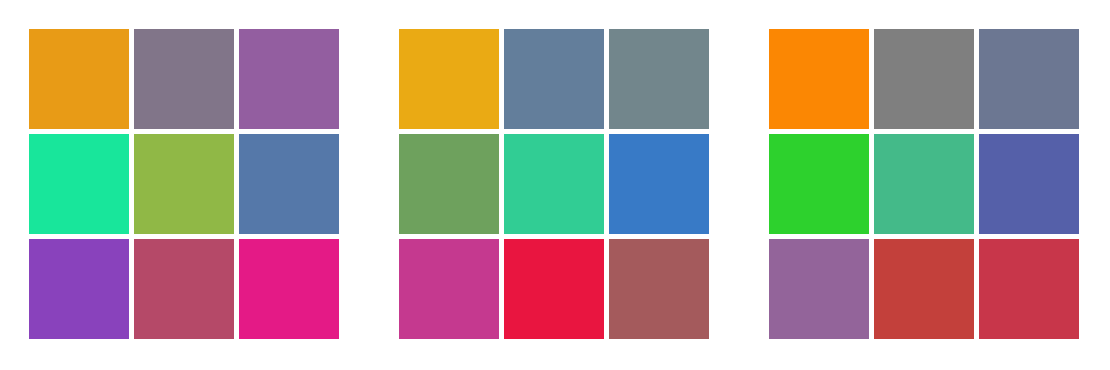

Position described by speaker: left
Response sentence: <think>

</think>

This grid is a 4x4 mosaic of solid-colored squares, each containing a distinct, pure hue. The squares are arranged in a regular 2x2 grid pattern across the image, with each 2x2 block containing four identical squares.

There are 16 squares in total.
The squares are arranged in 2x2 blocks, with each 2x2 block containing four identical squares.

The colors are distinct and solid.
The colors are:
- Orange
- Purple
- Green
- Blue
- Red
- Teal
- Green (appears twice)
- Purple (appears twice)
- Pink (appears twice)
 




In [ ]:
####Qwen3.5-0.8B
print("Qwen3.5-0.8B thinking off")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Qwen3.5-9B thinking off
Entry 2271


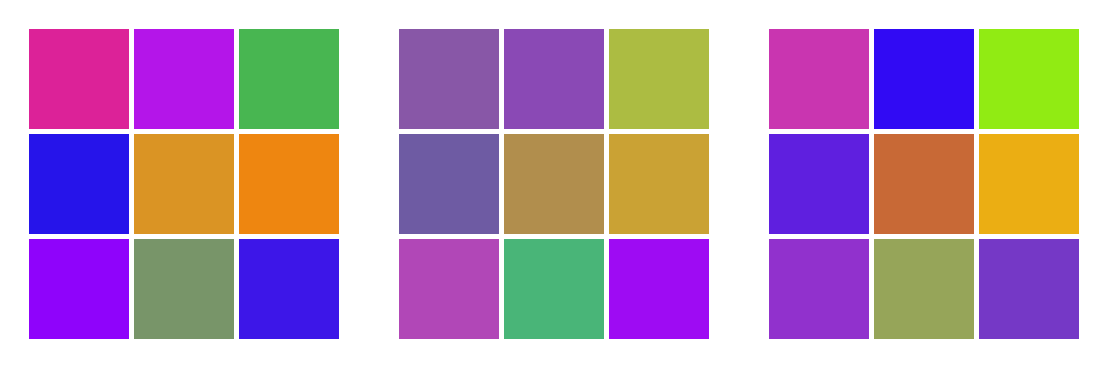

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid contains a bright magenta square in the top-left corner and a vivid orange square in the center-right position. These two colors are unique to this grid compared to the other two.
 


Entry 8698


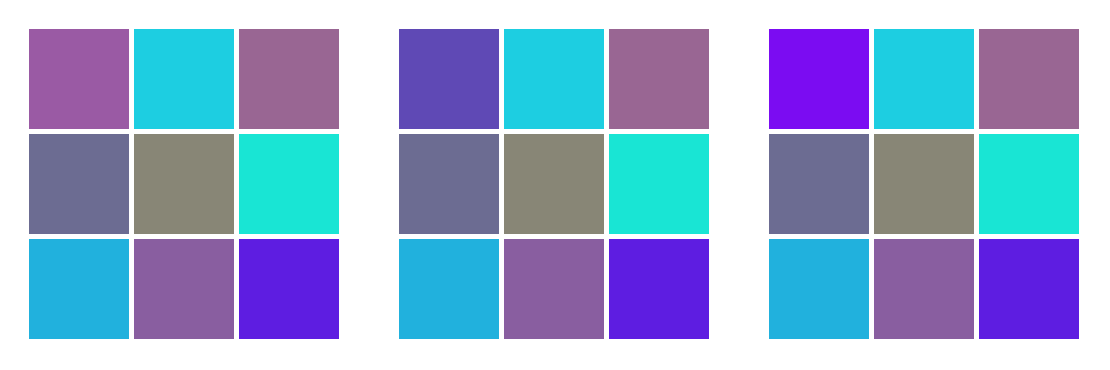

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid contains a bright purple square in the bottom-right corner, which is more vivid and saturated than the purple squares in the other two grids. Additionally, the top-left square in this grid is a muted lavender-purple, distinct from the deeper violet tones found in the other grids.
 


Entry 3753


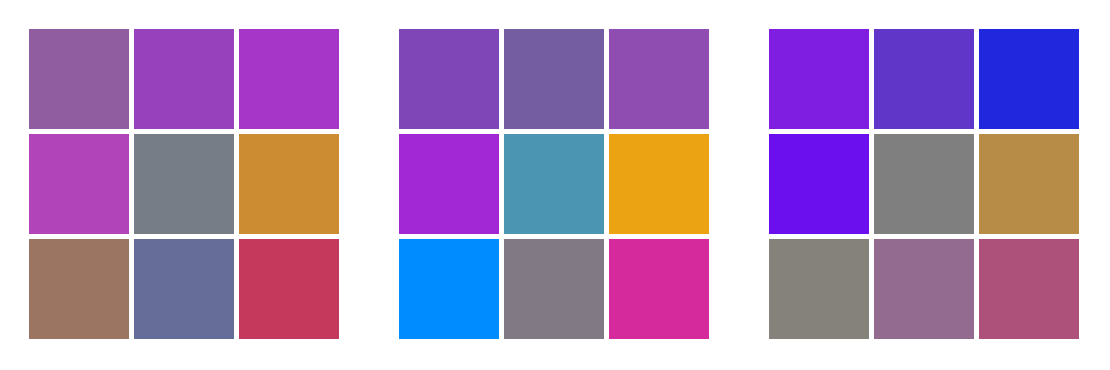

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The right grid contains a bright blue square in the top-right corner, which is not present in the other two grids. Additionally, it includes a vibrant purple square in the middle-left position and a deep magenta square in the bottom-right corner — both of which are unique to this grid compared to the others. These distinct, saturated colors make it easily identifiable.
 


Entry 8665


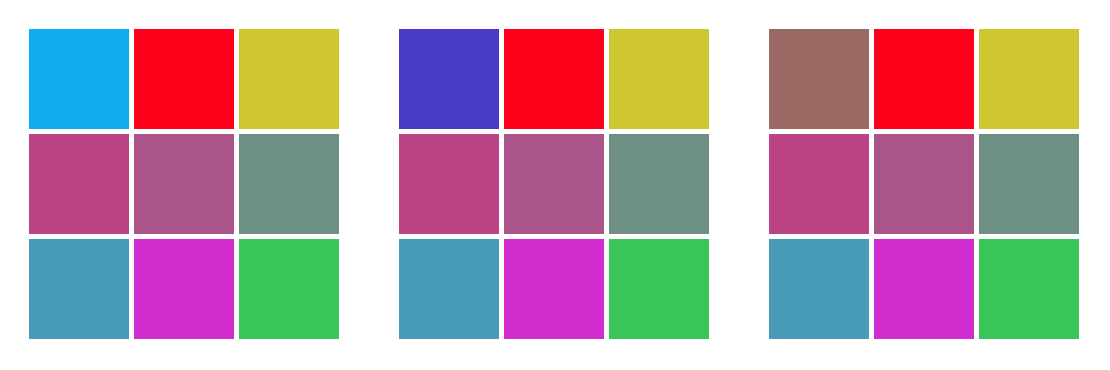

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The left grid is the only one containing a bright cyan square in the top-left corner.
 


Entry 4441


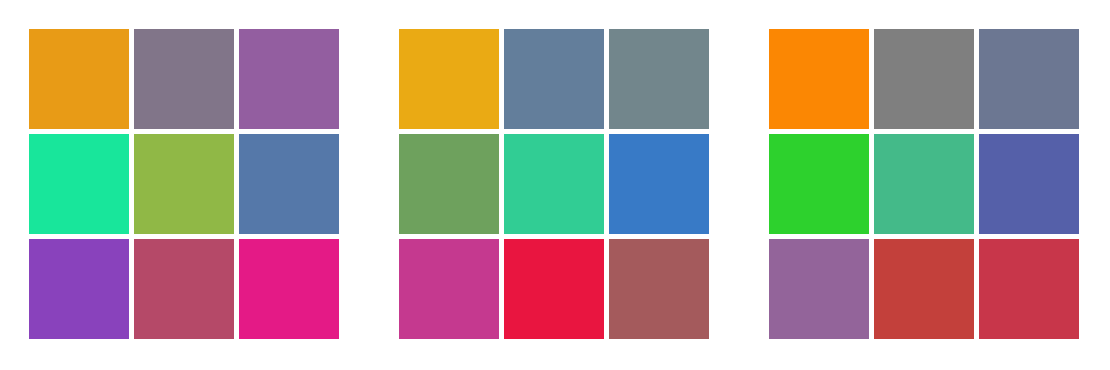

Position described by speaker: left
Response sentence: <think>

</think>

To identify the left grid, focus on these distinctive features:

- The top-left square is a bright, saturated orange (distinctly different from the more muted or yellow-orange tones in the other grids).
- The bottom-left square is a deep purple (not to be confused with the lighter lavender-like purple in the middle grid or the reddish-purple in the right grid).
- The bottom-right square is a vivid magenta/pink — this color does not appear in the other two grids.

These three colors — especially the bright orange at the top-left and the magenta at the bottom-right — are unique to the left grid and will help you pinpoint it.
 




In [7]:
####Qwen3.5-9B
print("Qwen3.5-9B thinking off")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

In [ ]:
####Molmo2-4B
print("Molmo2-4B")


from data_prep.data_utils import build_grid_image

old_responses = new_responses
new_responses = []

for i, entry in data_df.sample(n=5, random_state=42).iterrows():
    print(f"Entry {i}")
    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)
    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")
    new_responses.append(response_sentence)

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Entry 2271
Generated response: <think>

</think>

The top-right cell of the grid contains a bright lime green square. This color is unique to this specific grid; the other grids use shades of purple, blue, orange, and brown, but none contain this particular lime green.



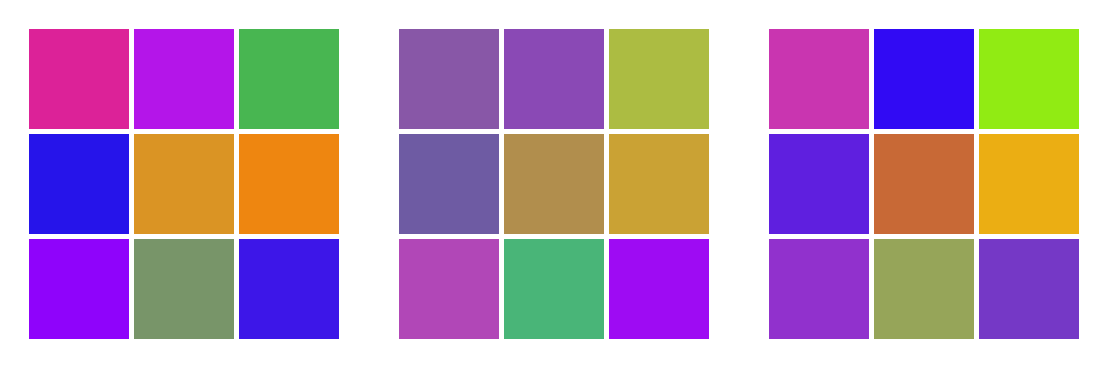

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The top-right cell of the grid contains a bright lime green square. This color is unique to this specific grid; the other grids use shades of purple, blue, orange, and brown, but none contain this particular lime green.
 


Entry 8698
Generated response: <think>

</think>

The first grid is distinguished by the presence of a bright turquoise square in its upper left corner, which contrasts with the other grids that feature purple or purple-blue squares in similar positions.



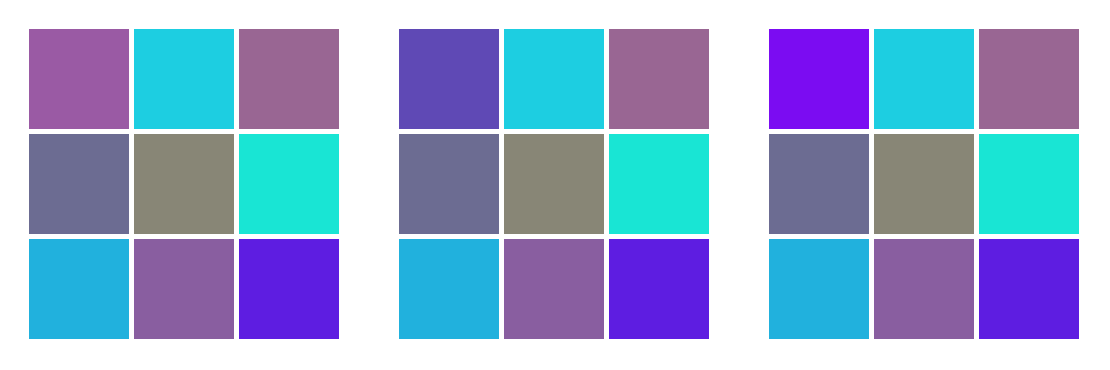

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The first grid is distinguished by the presence of a bright turquoise square in its upper left corner, which contrasts with the other grids that feature purple or purple-blue squares in similar positions.
 


Entry 3753
Generated response: <think>

</think>

The grid containing a bright violet square in the top-left corner and a dark blue square in the top-right corner.



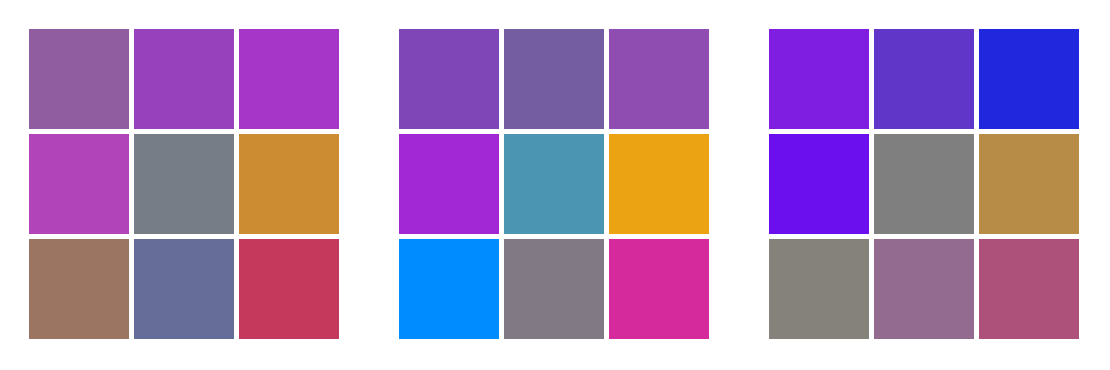

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The grid containing a bright violet square in the top-left corner and a dark blue square in the top-right corner.
 


Entry 8665
Generated response: <think>

</think>

The grid can be identified by its top-left square, which is a bright cyan blue. This color is unique to this grid compared to the other two. Additionally, the square directly below the cyan blue one is a muted purple or magenta shade. The top-right square in this grid is a light olive yellow. These specific color combinations in the top row distinguish it from the others.



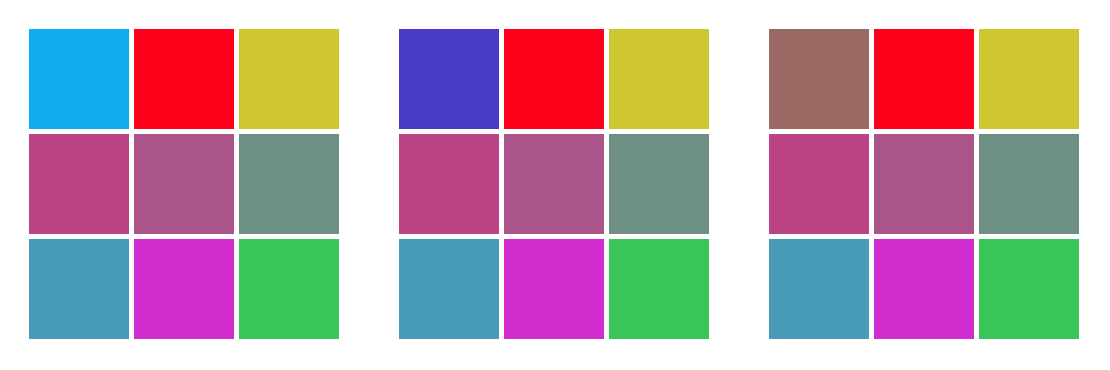

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The grid can be identified by its top-left square, which is a bright cyan blue. This color is unique to this grid compared to the other two. Additionally, the square directly below the cyan blue one is a muted purple or magenta shade. The top-right square in this grid is a light olive yellow. These specific color combinations in the top row distinguish it from the others.
 


Entry 4441
Generated response: <think>

</think>

This grid contains a bright turquoise square in the second row, first column, which stands out among the other squares of similar or muted colors.



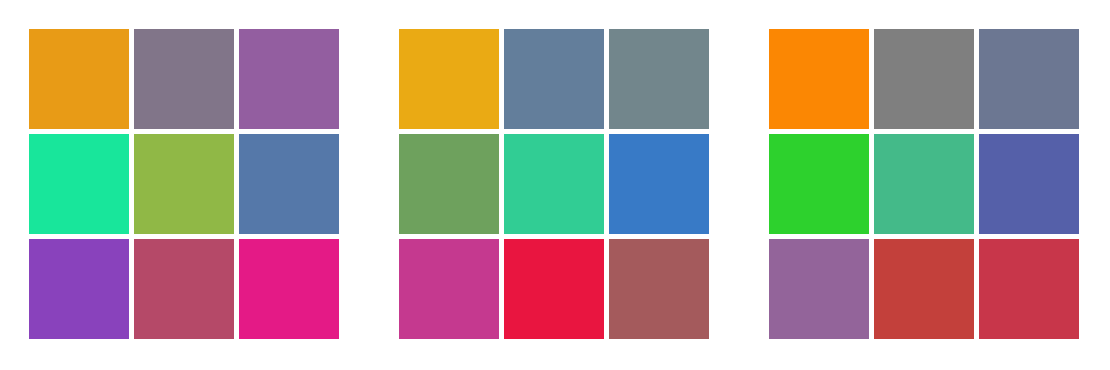

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

This grid contains a bright turquoise square in the second row, first column, which stands out among the other squares of similar or muted colors.
 


Entry 7868
Generated response: <think>

</think>

The grid with a dark purple square at the bottom right corner.



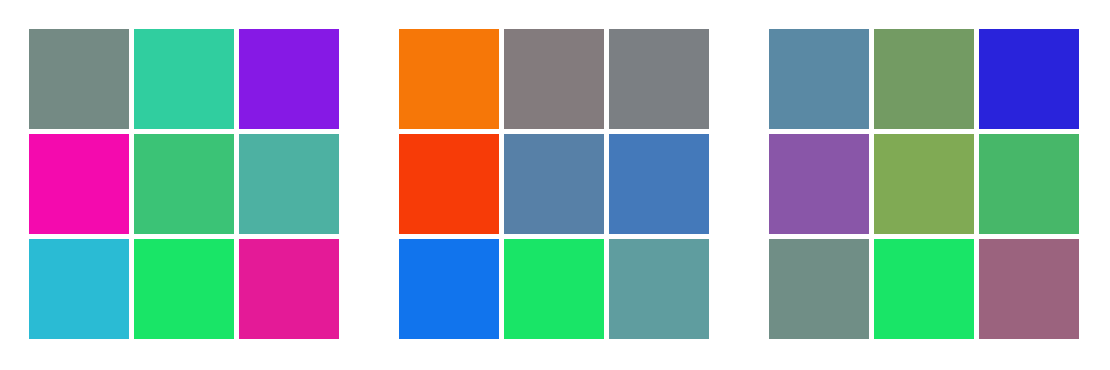

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: right
Response sentence: <think>

</think>

The grid with a dark purple square at the bottom right corner.
 


Entry 10859
Generated response: <think>

</think>

The grid with a **red square at the top-center** can be identified.

More specifically:
- The **top row** contains: a **red square** (left), a **green square** (center), and a **blue square** (right).
- The **middle row** has: a **purple square** on the left, a **yellow square** in the center, and a **green square** on the right.
- The **bottom row** features: a **blue square** on the left, a **brown square** in the center, and a **red square** on the right.

This arrangement — particularly the red square at the top-left and red square at the bottom-right — makes it


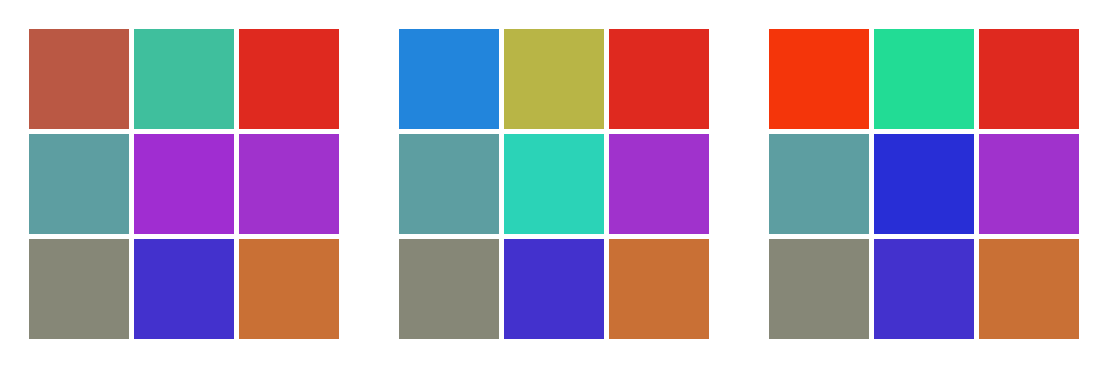

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The grid with a **red square at the top-center** can be identified.

More specifically:
- The **top row** contains: a **red square** (left), a **green square** (center), and a **blue square** (right).
- The **middle row** has: a **purple square** on the left, a **yellow square** in the center, and a **green square** on the right.
- The **bottom row** features: a **blue square** on the left, a **brown square** in the center, and a **red square** on the right.

This arrangement — particularly the red square at the top-left and red square at the bottom-right — makes it 


Entry 932
Generated response: <think>

</think>

The grid that can be identified is the one containing a bright green square in its top-left corner and a deep blue square directly to its right. Additionally, this grid features a yellow-green square in the top-right position.



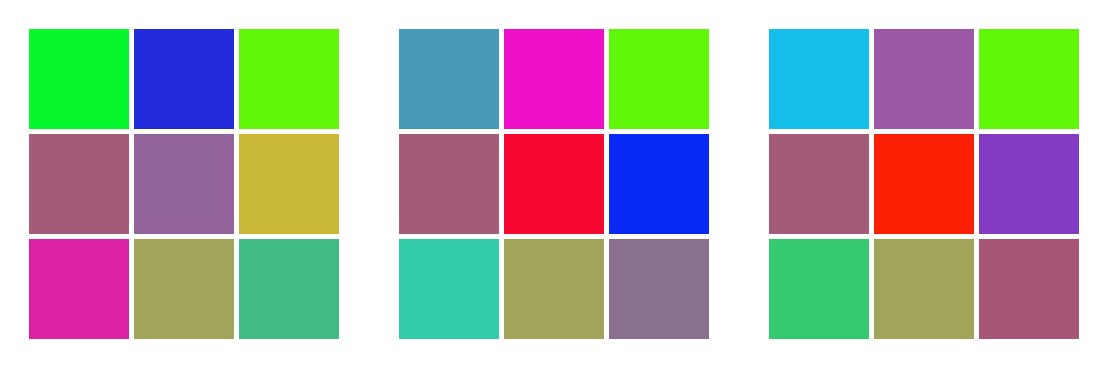

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

The grid that can be identified is the one containing a bright green square in its top-left corner and a deep blue square directly to its right. Additionally, this grid features a yellow-green square in the top-right position.
 


Entry 5279
Generated response: <think>

</think>

This grid is identifiable by its top row, which consists of a bright green square on the far left, followed by a reddish-brown square, and then a muted purple-gray square. The second row begins with a light green square, a vivid purple square, and a medium blue square. The bottom row features an olive-green square, a darker brownish-green square, and a dusty rose or muted red square.



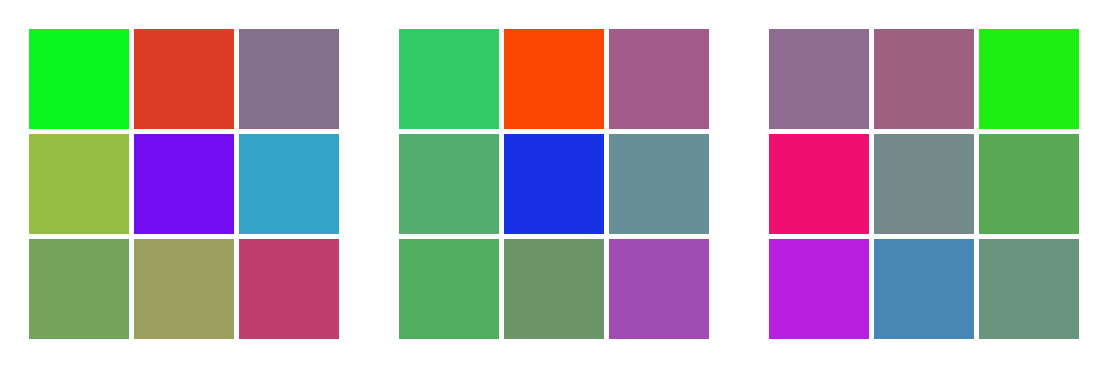

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Position described by speaker: left
Response sentence: <think>

</think>

This grid is identifiable by its top row, which consists of a bright green square on the far left, followed by a reddish-brown square, and then a muted purple-gray square. The second row begins with a light green square, a vivid purple square, and a medium blue square. The bottom row features an olive-green square, a darker brownish-green square, and a dusty rose or muted red square.
 


Entry 304
Generated response: <think>

</think>

The middle grid can be identified by the presence of a bright magenta square in its top-right corner, which is distinct from the other grids. This magenta square is adjacent to a grey square on its left and a green square below it. Additionally, the bottom-left square in this grid is a deep purple, differing from the other grids where the bottom-left square is either a light purple or green.



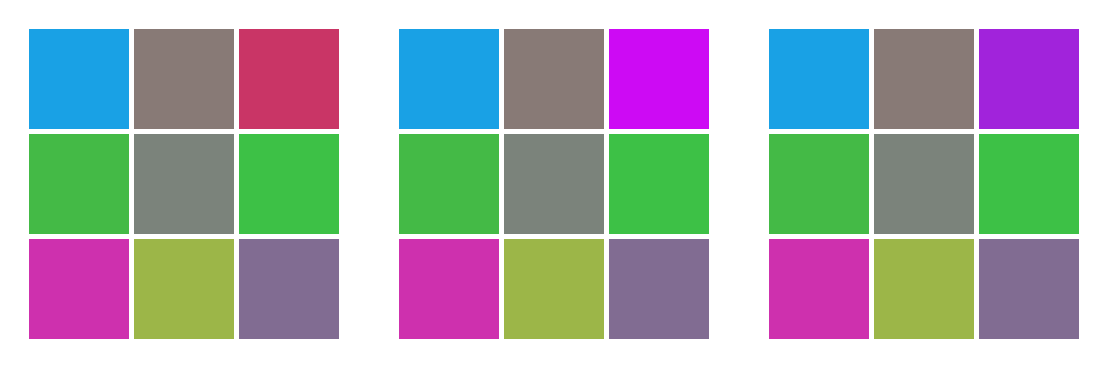

Position described by speaker: middle
Response sentence: <think>

</think>

The middle grid can be identified by the presence of a bright magenta square in its top-right corner, which is distinct from the other grids. This magenta square is adjacent to a grey square on its left and a green square below it. Additionally, the bottom-left square in this grid is a deep purple, differing from the other grids where the bottom-left square is either a light purple or green.
 




In [7]:
from data_prep.data_utils import build_grid_image
import base64
from io import BytesIO
from PIL import Image

html_file = open("generated_responses_qwen3_5_4B.html", "w", encoding="utf-8")

def write_html(text):
    html_file.write(text + "<br>\n")


old_responses = new_responses
new_responses = []

html_file.write(f"<h1>Model: Qwen3.5-4B</h1>")

for i, entry in data_df.sample(n=10, random_state=42).iterrows():
    print(f"Entry {i}")
    write_html(f"<b>Entry {i}</b>")

    img = build_grid_image(entry.objs, entry.speaker_order, **img_kwargs)
    position = ""
    if entry.target == 0:
        position = "left"
    elif entry.target == 1:
        position = "middle"
    elif entry.target == 2:
        position = "right"

    full_prompt = ' '.join([SPEAKER_PROMPT_ONE, position, SPEAKER_PROMPT_TWO])
    #print(f"Full prompt: {full_prompt}")
    response_sentence = model.generate(full_prompt, img, **generate_kwargs)
    display(img)

    buffer = BytesIO()
    img.save(buffer, format="PNG")
    img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    write_html(f'<img src="data:image/png;base64,{img_base64}">')

    print(f"Position described by speaker: {position}")
    print(f"Response sentence: {response_sentence} \n\n")

    write_html(f"Position described by speaker: {position}")
    write_html(f"Response sentence: {response_sentence}")
    write_html("<hr>")

    new_responses.append(response_sentence)

html_file.close()

In [12]:


for i in range(5):
    if old_responses[i] != new_responses[i]:
        print(f"Response changed for entry {i}")
    else:
        print(f"Response did not change for entry {i}")

Response changed for entry 0
Response changed for entry 1
Response changed for entry 2
Response changed for entry 3
Response changed for entry 4


In [7]:
print(model.model.generation_config)
model.model.generation_config.temperature = 0.7

GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "repetition_penalty": 1.0,
  "temperature": 0.7,
  "top_k": 1,
  "top_p": 0.001
}



In [ ]:


response_sentence = model.generate(
            full_prompt, img, prune_output_to_response=True, **generate_kwargs)